## Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
| :--- | :--- |
| **Percepción (S)** | `ingreso_mensual` (S/.), `monto_solicitado` (S/.), `tiene_historial_moroso` (booleano) |
| **Acciones (A)** | "aprobar", "aprobar con condiciones", "rechazar" |
| **Entorno (E)** | Sistema web de evaluación crediticia bancario |
| **Objetivo** | Minimizar el riesgo de impago garantizando el otorgamiento de préstamos viables |
| **Medida de desempeño (P)** | Tasa de morosidad, retorno financiero sobre la cartera y tasa de conversión |

### Justificación de las reglas
Las reglas priorizan la gestión de riesgo crediticio del banco: una relación monto/ingreso superior a 0.5 sobrepasa la Capacidad del cliente y se rechaza. 
Si existe historial moroso previo junto a una relación superior a 0.3, el riesgo de mora reiterada obliga al rechazo. 
Para relaciones intermedias (hasta 0.5) o morosidades leves, se aprueba con condiciones requiriendo un aval o garantía para mitigar el riesgo.

### Código

In [12]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Evalúa una solicitud de crédito bancario según el ingreso, monto e historial moroso.
    Retorna una tupla: (accion, motivo).
    """
    # Validación básica: el ingreso debe ser mayor a cero
    if ingreso_mensual <= 0:
        return "rechazar", "ingreso mensual invalido o igual a cero"
    
    # Proporción del crédito respecto al ingreso del cliente
    relacion = monto_solicitado / ingreso_mensual
    
    # Regla 1: Rechazo directo si registra historial moroso
    if tiene_historial_moroso:
        return "rechazar", f"relacion monto/ingreso de {relacion:.2f} con historial moroso registrado"
    
    # Regla 2: Rechazo si el monto pedido supera el 50% de sus ingresos
    elif relacion > 0.5:
        return "rechazar", f"relacion monto/ingreso de {relacion:.2f} supera el limite maximo de 0.5"
    
    # Regla 3: Aprobación condicional si el monto representa entre el 25% y 50%
    elif 0.25 < relacion <= 0.5:
        return "aprobar con condiciones", f"relacion monto/ingreso moderada ({relacion:.2f}), requiere garantias adicionales"
    
    # Regla 4: Aprobación limpia si el monto es hasta el 25% y no tiene morosidad
    else:
        return "aprobar", f"relacion monto/ingreso baja ({relacion:.2f} <= 0.25) y sin historial moroso"

 ### Simulación y pruebas

In [13]:
# Lista con casos de prueba almacenados como tuplas:
# Formato de cada tupla: (ingreso, monto, tiene_morosidad)
casos_prueba_credito = [
    (5000, 1000, False),  # Relación = 0.20 -> Aprobar
    (4000, 1000, False),  # Caso borde: Relación = 0.25 -> Aprobar
    (4000, 1400, False),  # Relación = 0.35 -> Aprobar con condiciones
    (4000, 2000, False),  # Caso borde: Relación = 0.50 -> Aprobar con condiciones
    (4000, 2400, False),  # Relación = 0.60 -> Rechazar por sobrepaso
    (8000, 1000, True)    # Relación = 0.125 -> Rechazar por morosidad
]

print("=== PRUEBAS DEL AGENTE DE CRÉDITO ===")

# Recorremos los casos con un bucle for.
# enumerate(..., 1) nos da un contador 'i' que inicia en 1 (en lugar del 0 habitual).
# (ingreso, monto, moroso) extrae los 3 datos de la tupla actual.
for i, (ingreso, monto, moroso) in enumerate(casos_prueba_credito, 1):
    
    # Llamamos a la función y guardamos sus dos retornos en 'accion' y 'motivo'
    accion, motivo = agente_credito(ingreso, monto, moroso)
    
    # Mostramos el resultado. accion.upper() convierte el texto a MAYÚSCULAS.
    print(f"Caso {i}: Ingreso=S/{ingreso}, Monto=S/{monto}, Moroso={moroso} | Decision: {accion.upper()} | Motivo: {motivo}")

=== PRUEBAS DEL AGENTE DE CRÉDITO ===
Caso 1: Ingreso=S/5000, Monto=S/1000, Moroso=False | Decision: APROBAR | Motivo: relacion monto/ingreso baja (0.20 <= 0.25) y sin historial moroso
Caso 2: Ingreso=S/4000, Monto=S/1000, Moroso=False | Decision: APROBAR | Motivo: relacion monto/ingreso baja (0.25 <= 0.25) y sin historial moroso
Caso 3: Ingreso=S/4000, Monto=S/1400, Moroso=False | Decision: APROBAR CON CONDICIONES | Motivo: relacion monto/ingreso moderada (0.35), requiere garantias adicionales
Caso 4: Ingreso=S/4000, Monto=S/2000, Moroso=False | Decision: APROBAR CON CONDICIONES | Motivo: relacion monto/ingreso moderada (0.50), requiere garantias adicionales
Caso 5: Ingreso=S/4000, Monto=S/2400, Moroso=False | Decision: RECHAZAR | Motivo: relacion monto/ingreso de 0.60 supera el limite maximo de 0.5
Caso 6: Ingreso=S/8000, Monto=S/1000, Moroso=True | Decision: RECHAZAR | Motivo: relacion monto/ingreso de 0.12 con historial moroso registrado


### Visualización

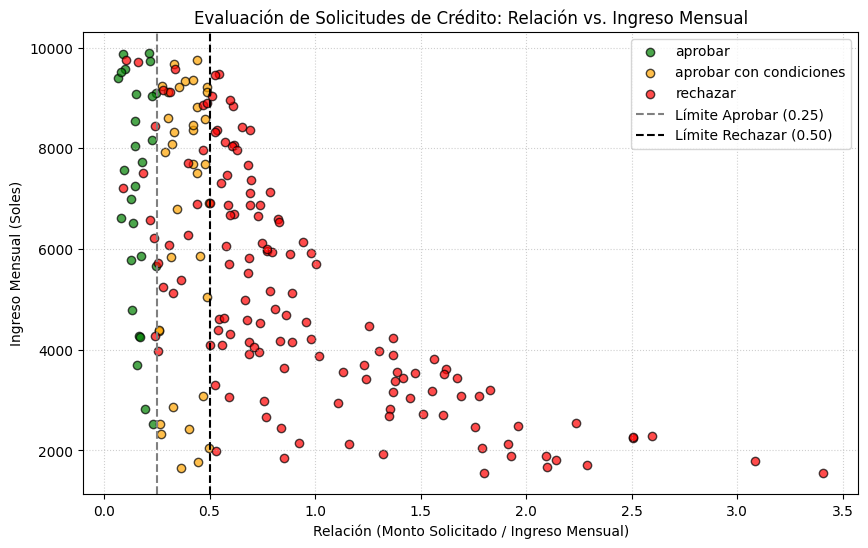

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Fijamos la semilla aleatoria para que siempre salgan los mismos datos al ejecutar
np.random.seed(42)
num_muestras = 200  # Cantidad de clientes simulados

# Generamos datos aleatorios para la prueba:
# 1. Ingresos entre 1500 y 10000
ingresos = np.random.uniform(1500, 10000, num_muestras)
# 2. Montos de crédito pedidos entre 500 y 6000
montos = np.random.uniform(500, 6000, num_muestras)
# 3. Historial moroso con probabilidades: 25% True (moroso) y 75% False (limpio)
historiales = np.random.choice([True, False], size=num_muestras, p=[0.25, 0.75])

# Operación vectorizada: calcula la relación (monto / ingreso) para los 200 clientes a la vez
relaciones = montos / ingresos
acciones = []  # Lista donde guardaremos la decisión tomada para cada cliente

# Recorremos los 3 arreglos en paralelo usando zip()
for ing, mon, mor in zip(ingresos, montos, historiales):
    # Evaluamos al cliente. Usamos '_' para ignorar el segundo valor retornado (el motivo)
    acc, _ = agente_credito(ing, mon, mor)
    acciones.append(acc)  # Guardamos solo la acción ("aprobar", "rechazar", etc.)

# Mapeo de colores: asocia cada posible respuesta con un color de Matplotlib
colores_mapa = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

# Creamos el lienzo del gráfico con tamaño 10x6 pulgadas
plt.figure(figsize=(10, 6))

# Agrupamos los puntos por categoría para graficarlos con su respectivo color y leyenda
for decision in ["aprobar", "aprobar con condiciones", "rechazar"]:
    # Comprensión de lista: obtiene las posiciones (índices) donde la acción coincide con la categoría actual
    indices = [i for i, a in enumerate(acciones) if a == decision]
    
    # Dibujamos los puntos en el mapa usando filtrado por índices en los arreglos de NumPy
    plt.scatter(
        relaciones[indices],       # Eje X: Valores de relación en esos índices
        ingresos[indices],         # Eje Y: Valores de ingreso en esos índices
        c=colores_mapa[decision], # Color asignado según el diccionario
        label=decision,            # Etiqueta que aparecerá en la leyenda
        alpha=0.7,                 # Nivel de transparencia (0.7 = 70% opaco)
        edgecolors='k'             # Borde negro alrededor de los puntos ('k' es negro)
    )

# Trazamos líneas verticales discontinuas en el eje X para señalar las fronteras de decisión
plt.axvline(x=0.25, color='gray', linestyle='--', label='Límite Aprobar (0.25)')
plt.axvline(x=0.50, color='black', linestyle='--', label='Límite Rechazar (0.50)')

# Textos y elementos estéticos
plt.title("Evaluación de Solicitudes de Crédito: Relación vs. Ingreso Mensual")
plt.xlabel("Relación (Monto Solicitado / Ingreso Mensual)")
plt.ylabel("Ingreso Mensual (Soles)")
plt.legend()  # Muestra el recuadro explicativo de colores y líneas
plt.grid(True, linestyle=':', alpha=0.6)  # Activa la cuadrícula punteada suave
plt.show()    # Despliega la ventana con el gráfico generado